# Retail Sales Performance Analysis (Superstore Dataset)

## End-to-End Data Analytics Project using Python

## Project Objective

The goal of this analysis is to identify sales trends, 
profitability patterns, and key business insights across regions, 
categories, and customers using the Superstore dataset.

## Dataset Overview

The dataset contains retail sales data including:
- Order Date
- Customer ID
- Region
- Category
- Sales
- Profit

In [15]:
import pandas as pd

# load dataset
df = pd.read_csv("../data/superstore.csv")

# show first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# see dataset shape
df.shape

# show columns
df.columns

# show data types
df.info()

# clean data
# identify missing values
df.isnull().sum()

# remove missing values
df = df.dropna()


In [17]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format = "mixed")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format = "mixed")

# extract year and month
df["order_year"] = df["Order Date"].dt.year
df["order_month"] = df["Order Date"].dt.month

# profit margin
df["profit_margin"] = df["Profit"] / df["Sales"]

# total sales
df["Sales"].sum()

# total profit
df["Profit"].sum()

# profit by category
df.groupby("Category")["Profit"].sum().sort_values(ascending = False)

# sales by region
df.groupby("Region")["Sales"].sum().sort_values(ascending = False)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

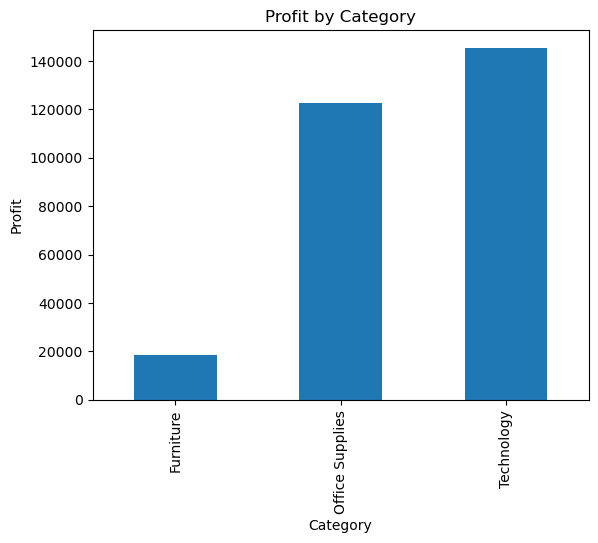

In [18]:
import matplotlib.pyplot as plt

# this is for the chart
df.groupby("Category")["Profit"].sum().plot(kind = "bar")

# labels for the chart
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

# demonstrates chart
plt.show()

# The graphic demonstrates that the most profitable category belongs to technology.

## Insight

Technology is the most profitable category, while furniture shows lower profitablity, 
suggesting potential cost or pricing inefficiencies.

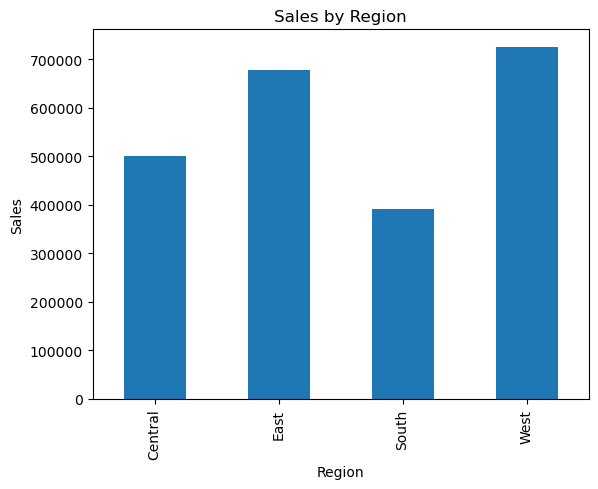

In [20]:
import matplotlib.pyplot as plt

# this is for the chart
df.groupby("Region")["Sales"].sum().plot(kind = "bar")

# labels for the chart
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

# demonstrates chart
plt.show()

# The graphic demonstrates a comparison in regions, indicating that the West region 
# has the highest total sales.

## Insight

The West region generates the highest total sales, meanwhile the South region
has the lowest performance. This indicates potential underperformance 
or smaller market size in the Southern region.

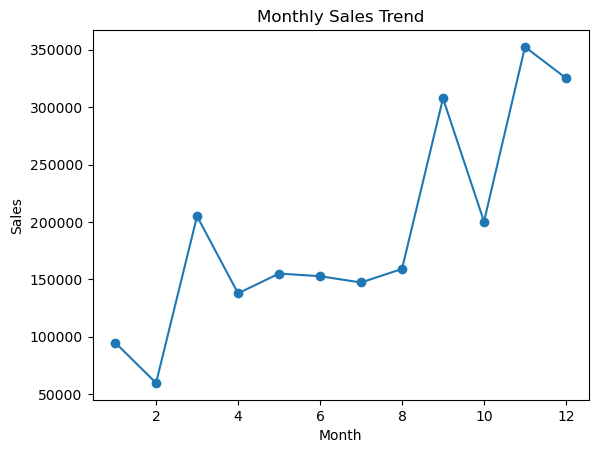

In [21]:
monthly_sales = df.groupby("order_month")["Sales"].sum()

monthly_sales.plot(kind = "line", marker = "o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

# This line chart identifies seasonal trends,
# along with the strongest and weakest months.

## Insight

The monthly sales trend shows noticable fluctuations in revenue throughout the 
year, with specific months consistently outperforming others.
This suggests that sales are influenced by seasonal demand patterns.

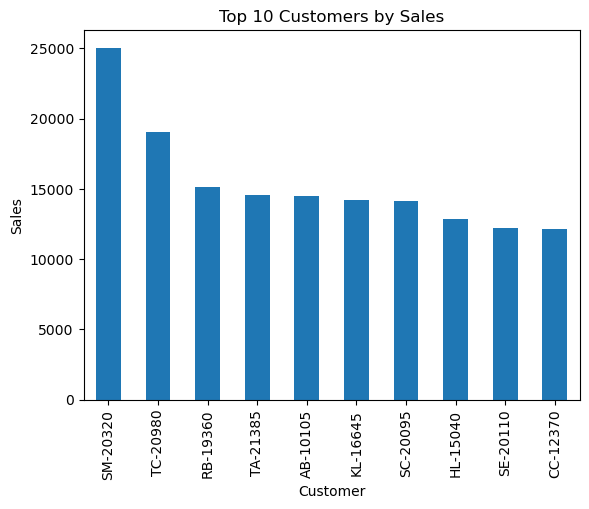

In [23]:
 # Top 10 customers by sales
top_customers = df.groupby("Customer ID")["Sales"].sum().sort_values(ascending = False).head(10)

top_customers

# graph for top 10 customers by sales
top_customers.plot(kind = "bar")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Sales")

plt.show()

## Insight

The Top 10 customers account for a significant portion of total sales, indicating
that revenue is heavily concentrated among a small group of high-value buyers.

This highlights the importance of customer retention strategies as maintaining 
\relationships with top customers can have a direct correlation on total revenue.

## Conclusion

This analysis revealed key business insights across categories, regions, and customers.
The West region leads in sales performance, while Technology is the most profitable category.
These insights can help guide strategic business decisions such as regional investment and 
product focus.

In [50]:
import sqlite3

conn = sqlite3.connect("../data/superstore.db")

df.to_sql("sales", conn, if_exists = "replace", index = False)


query = """
SELECT Category, SUM(Profit) as total_sales
FROM sales
GROUP BY Category
ORDER BY total_sales DESC;
"""

pd.read_sql(query, conn)


,Category,total_sales
0,Technology,145454.9481
1,Office Supplies,122490.8008
2,Furniture,18451.2728


In [47]:

query = """
SELECT Region, SUM(Sales) as total_sales
FROM sales
GROUP BY Region
ORDER BY total_sales DESC;
"""

pd.read_sql(query, conn)


,Region,total_sales
0,West,725457.8245
1,East,678781.2400
2,Central,501239.8908
3,South,391721.9050


In [48]:
query = """
SELECT "Customer ID", SUM(Sales) as total_sales
FROM sales
GROUP BY "Customer ID"
ORDER BY total_sales DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,Customer ID,total_sales
0,SM-20320,25043.050
1,TC-20980,19052.218
2,RB-19360,15117.339
3,TA-21385,14595.620
4,AB-10105,14473.571
5,KL-16645,14175.229
6,SC-20095,14142.334
7,HL-15040,12873.298
8,SE-20110,12209.438
9,CC-12370,12129.072


In [37]:
df.to_csv("../data/clean_superstore.csv", index = False)